In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [21]:
df['sales'].value_counts()

sales
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

### Analysis

Sales should be renamed as Department.

In [22]:
df.rename(columns={'sales': 'Department'}, inplace=True)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [23]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

## Doing Ordinal coding for Salary column

In [24]:
df['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [25]:
salary_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['salary'] = df['salary'].map(salary_mapping)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,0
1,0.80,0.86,5,262,6,0,1,0,sales,1
2,0.11,0.88,7,272,4,0,1,0,sales,1
3,0.72,0.87,5,223,5,0,1,0,sales,0
4,0.37,0.52,2,159,3,0,1,0,sales,0


## Performing one Hot encoding for Department Column

In [26]:
df = pd.get_dummies(df, columns=['Department'], drop_first=True, dtype=int)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,1,0,0


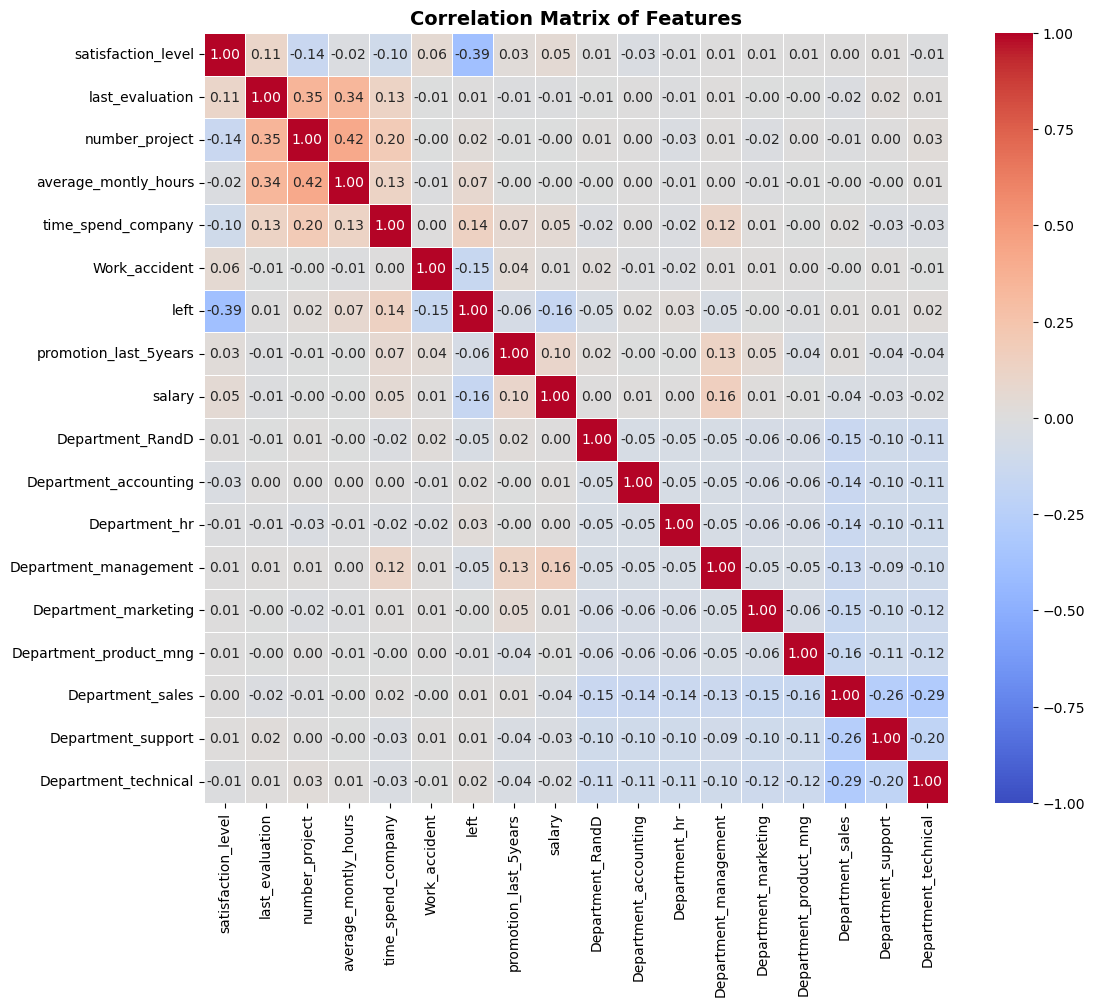

In [27]:
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Features', size=14, weight='bold')
plt.show()

In [30]:
top_factors = corr[(corr['left'].abs()>0.05) & (corr['left'].abs()<1)]['left']
top_factors

satisfaction_level      -0.388375
average_montly_hours     0.071287
time_spend_company       0.144822
Work_accident           -0.154622
promotion_last_5years   -0.061788
salary                  -0.157898
Name: left, dtype: float64

### Analysis

- Workers with lower satisfaction level are more likely to leave the company.<br>
- workers with higher average monthly hours are more likely to leave the company.<br>
- Workers spending more time at the company are more likely to leave the company.<br>
- workers with no work accidents are more likely to leave the company.<br>
- workers with no promotions are more likely to leave the company.<br>
- workers with salary on lower side are more likely to leave the company.<br>


In [31]:
summary = df.groupby('left').mean(numeric_only=True)
display(summary)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
left,,,,,,,,,,,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251,0.650945,0.058278,0.049265,0.045852,0.047165,0.057315,0.061603,0.273539,0.146482,0.177021
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321,0.414730,0.033884,0.057127,0.060207,0.025483,0.056847,0.055447,0.283954,0.155419,0.195183


In [ ]:
plt.figure(figsize=(8, 5))
sns.distplot(data = df, x = 'satisfaction_level',)

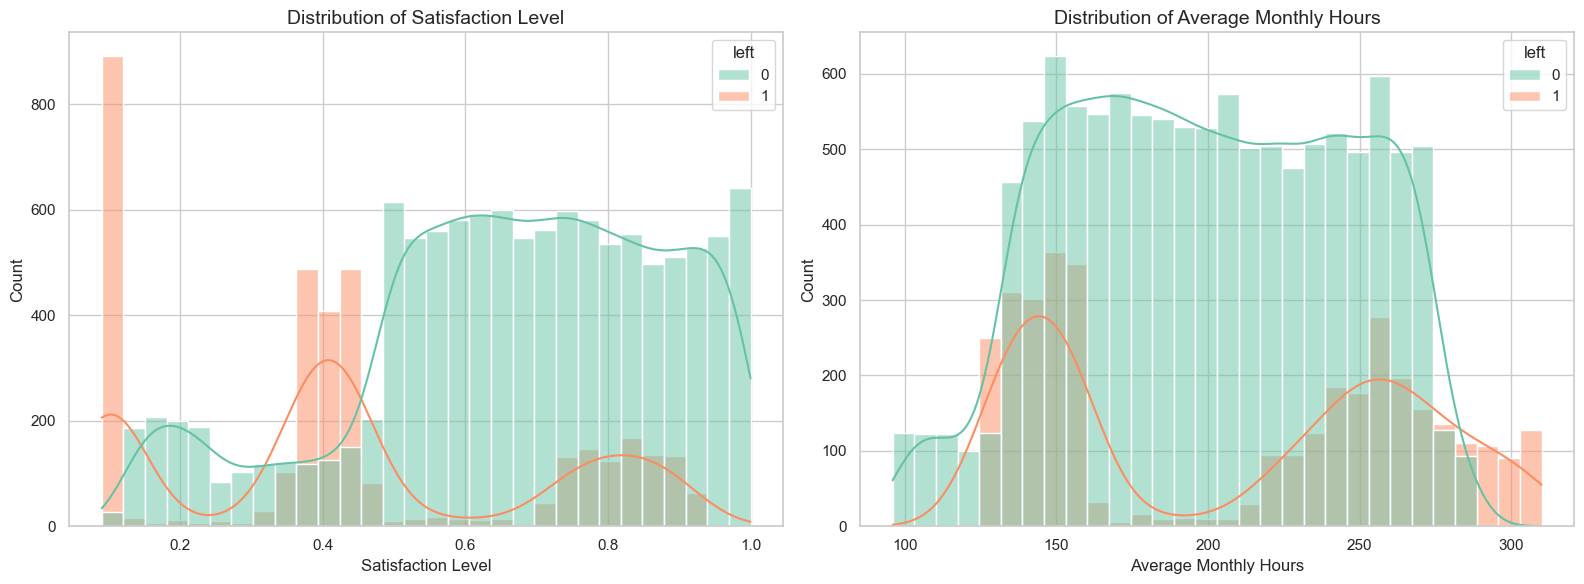

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic parameters for better-looking charts
sns.set_theme(style="whitegrid")

# Create a figure with subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Satisfaction Level for Left vs Stayed
sns.histplot(data=df, x="satisfaction_level", hue="left", kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("Distribution of Satisfaction Level", fontsize=14)
axes[0].set_xlabel("Satisfaction Level")
axes[0].set_ylabel("Count")

# Distribution of Average Monthly Hours for Left vs Stayed
sns.histplot(data=df, x="average_montly_hours", hue="left", kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Distribution of Average Monthly Hours", fontsize=14)
axes[1].set_xlabel("Average Monthly Hours")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_5263/3172052719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="left", y="time_spend_company", ax=axes[0], palette="Set2")


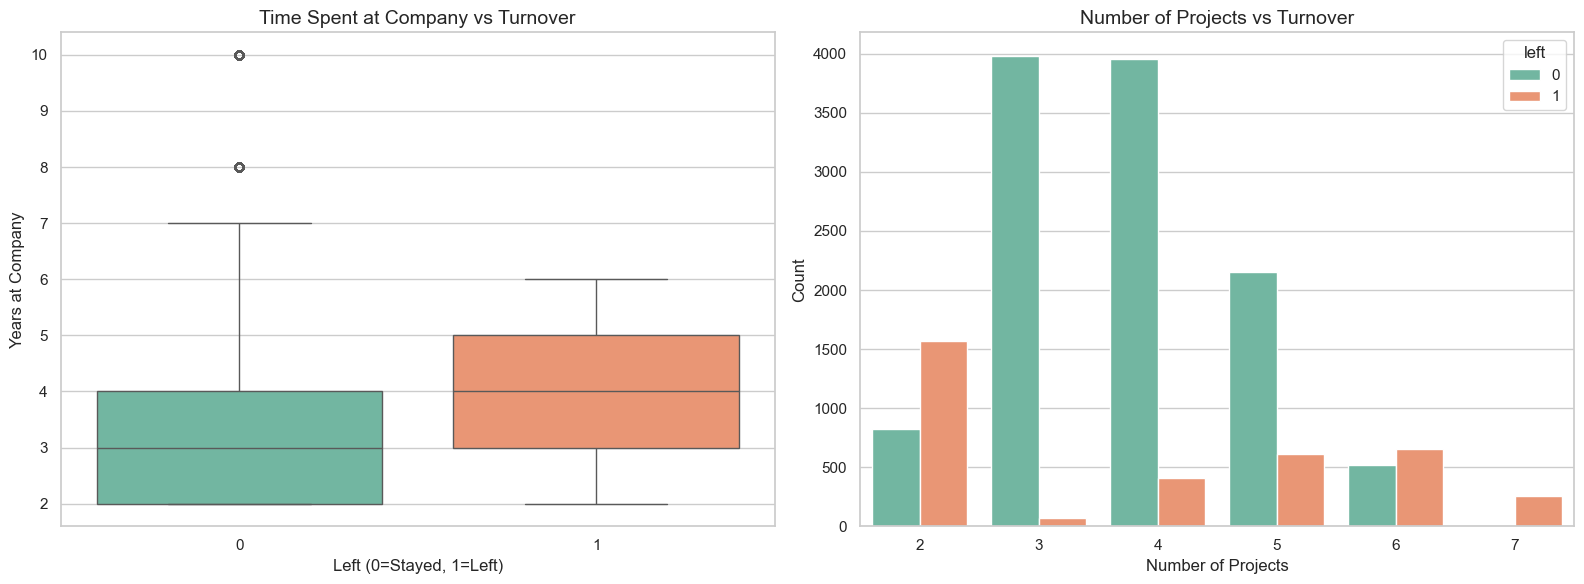

In [36]:

# Create a second figure for the next two plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for Time Spent at Company vs Turnover
sns.boxplot(data=df, x="left", y="time_spend_company", ax=axes[0], palette="Set2")
axes[0].set_title("Time Spent at Company vs Turnover", fontsize=14)
axes[0].set_xlabel("Left (0=Stayed, 1=Left)")
axes[0].set_ylabel("Years at Company")

# Countplot for Number of Projects vs Turnover
sns.countplot(data=df, x="number_project", hue="left", ax=axes[1], palette="Set2")
axes[1].set_title("Number of Projects vs Turnover", fontsize=14)
axes[1].set_xlabel("Number of Projects")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


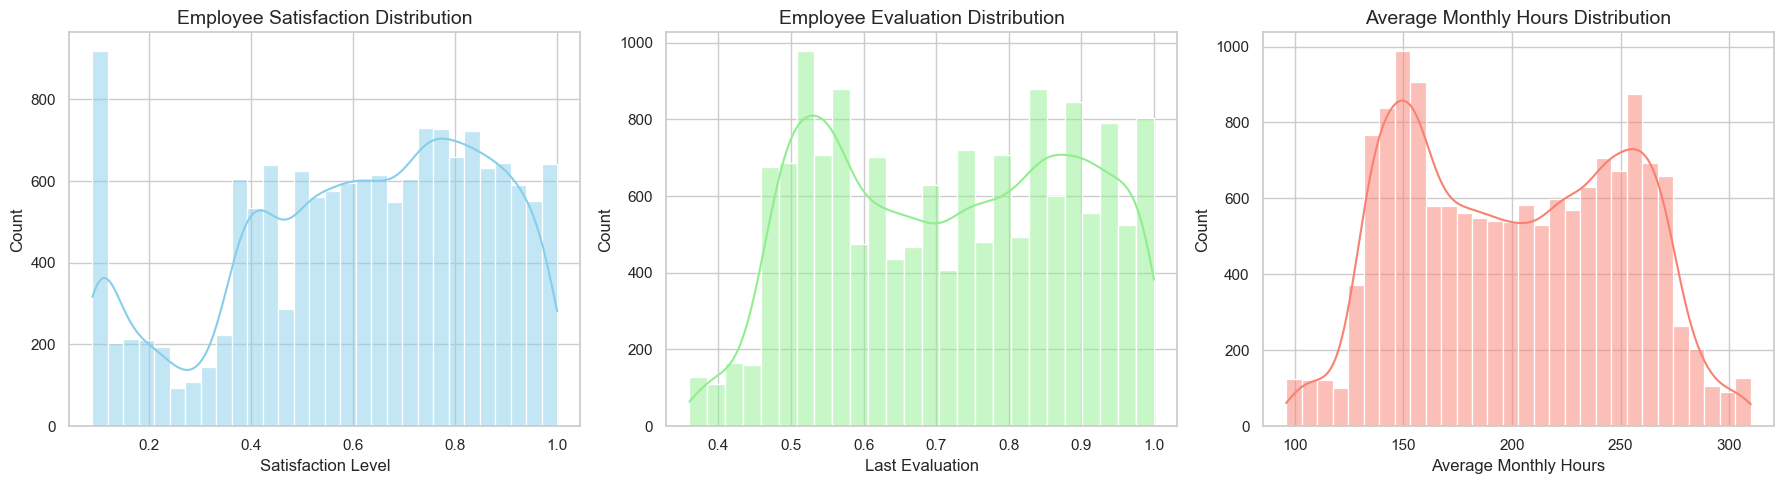

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for cleaner graphs
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Employee Satisfaction
sns.histplot(data=df, x="satisfaction_level", kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("Employee Satisfaction Distribution", fontsize=14)
axes[0].set_xlabel("Satisfaction Level")

# Plot 2: Employee Evaluation
sns.histplot(data=df, x="last_evaluation", kde=True, color="lightgreen", ax=axes[1])
axes[1].set_title("Employee Evaluation Distribution", fontsize=14)
axes[1].set_xlabel("Last Evaluation")

# Plot 3: Average Monthly Hours
sns.histplot(data=df, x="average_montly_hours", kde=True, color="salmon", ax=axes[2])
axes[2].set_title("Average Monthly Hours Distribution", fontsize=14)
axes[2].set_xlabel("Average Monthly Hours")

# Adjust spacing so titles don't overlap
plt.tight_layout()
plt.show()


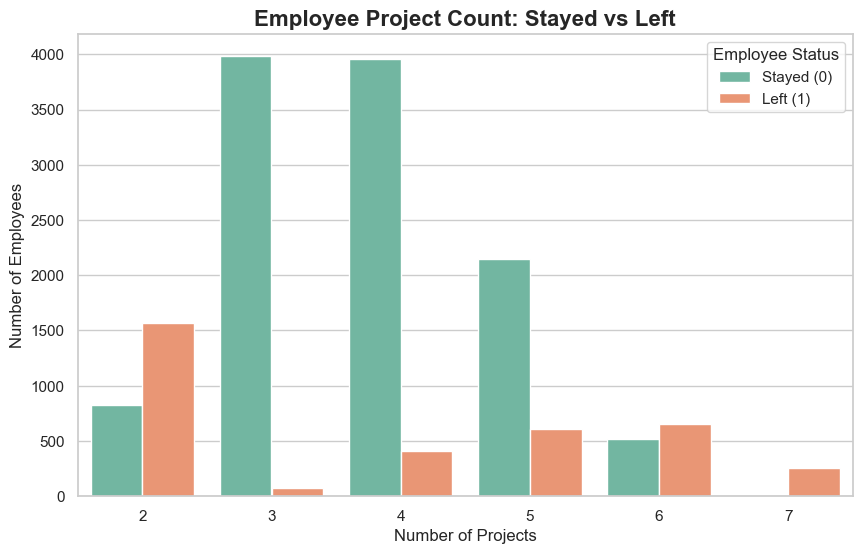

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a countplot for number of projects, separated by who left and stayed
sns.countplot(data=df, x='number_project', hue='left', palette='Set2')

# Add labels and a title
plt.title('Employee Project Count: Stayed vs Left', fontsize=16, weight='bold')
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

# Update legend for better readability
plt.legend(title='Employee Status', labels=['Stayed (0)', 'Left (1)'])

# Show the plot
plt.show()


### Analysis

Employee turnover is heavily driven by poor workload management. The company is losing employees because they are either extremely underworked (2 projects) or severely overworked (6+ projects).


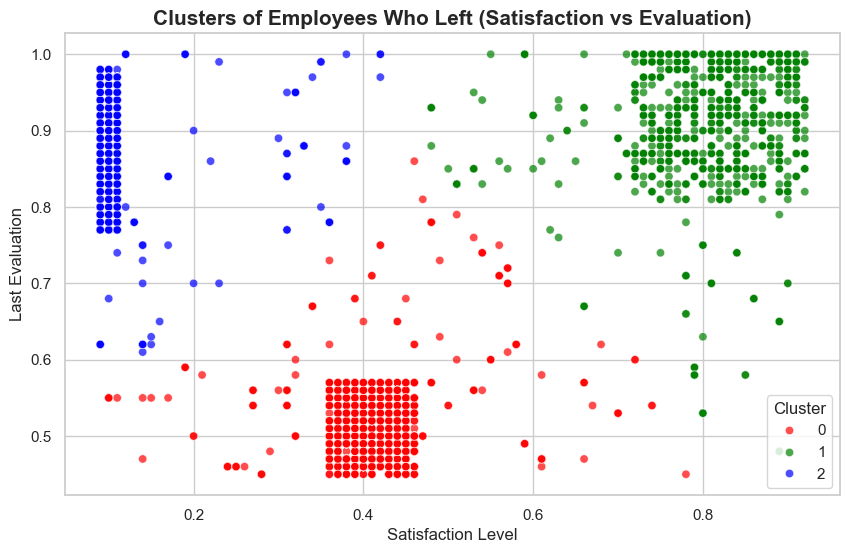

Cluster Centers (Averages):
         satisfaction_level  last_evaluation
cluster                                     
0                  0.410145         0.516982
1                  0.808516         0.911709
2                  0.111155         0.869301


In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset to include ONLY employees who left
left_emp = df[df['left'] == 1]

# 2. Select the two columns required for clustering
X = left_emp[['satisfaction_level', 'last_evaluation']]

# 3. Perform K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# Add the predicted cluster labels back to our filtered dataframe
left_emp = left_emp.copy() # Avoid SettingWithCopyWarning
left_emp['cluster'] = kmeans.fit_predict(X)

# 4. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=left_emp, 
    x='satisfaction_level', 
    y='last_evaluation', 
    hue='cluster', 
    palette=['red', 'green', 'blue'], 
    alpha=0.7
)

# Add title and labels
plt.title('Clusters of Employees Who Left (Satisfaction vs Evaluation)', fontsize=15, weight='bold')
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Last Evaluation', fontsize=12)
plt.legend(title='Cluster')
plt.show()

# 5. Print the Mean Values of Each Cluster to Understand Them
cluster_summary = left_emp.groupby('cluster')[['satisfaction_level', 'last_evaluation']].mean()
print("Cluster Centers (Averages):")
print(cluster_summary)


In [46]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 2. SEPARATE FEATURES (X) AND TARGET (y)
X = df.drop('left', axis=1)
y = df['left']

# 3. STRATIFIED TRAIN-TEST SPLIT (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=123, 
    stratify=y  # This ensures the train/test sets have the same proportion of 'left'
)

print(f"Original Training Target Counts:\n{y_train.value_counts()}\n")

# 4. UPSAMPLE USING SMOTE
smote = SMOTE(random_state=123)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE Training Target Counts:\n{y_train_smote.value_counts()}")


Original Training Target Counts:
left
0    9142
1    2857
Name: count, dtype: int64

SMOTE Training Target Counts:
left
0    9142
1    9142
Name: count, dtype: int64


Training Logistic Regression with 5-fold CV...


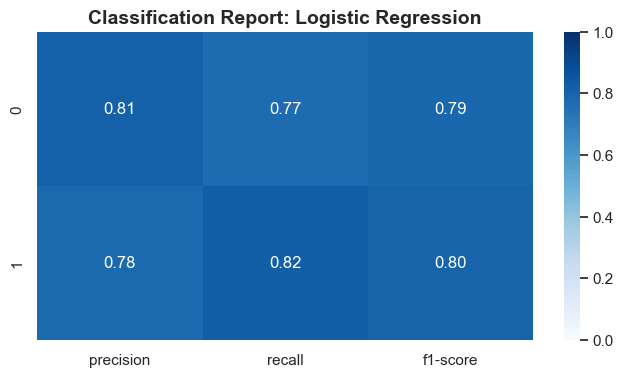


--- Detailed Text Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.79     18284
   macro avg       0.79      0.79      0.79     18284
weighted avg       0.79      0.79      0.79     18284

Training Random Forest with 5-fold CV...


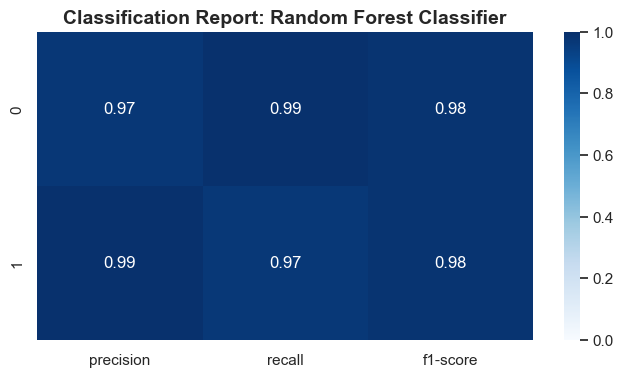


--- Detailed Text Report for Random Forest Classifier ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      9142
           1       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284

Training Gradient Boosting with 5-fold CV...


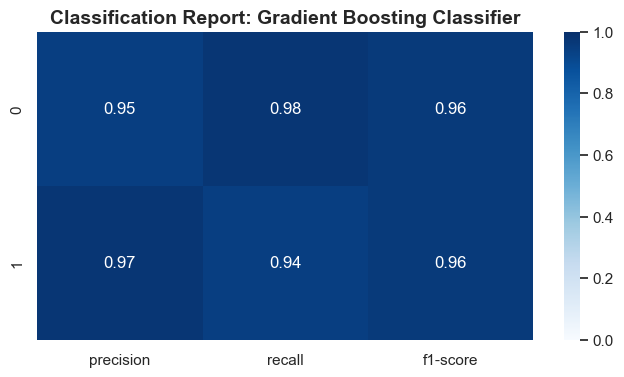


--- Detailed Text Report for Gradient Boosting Classifier ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.97      0.94      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

def plot_classification_report(y_true, y_pred, title):
    """
    Helper function to plot the classification report as a Seaborn heatmap
    and then print the standard text report below it.
    """
    # 1. Generate report dictionary
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # 2. Convert to DataFrame, drop accuracy/macro/weighted averages for a cleaner heatmap
    df_report = pd.DataFrame(report).iloc[:-1, :2].T
    
    # 3. Plot the heatmap
    plt.figure(figsize=(8, 4))
    sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1)
    plt.title(f"Classification Report: {title}", fontsize=14, weight="bold")
    plt.show()
    
    # 4. Print the actual text report
    print(f"\n--- Detailed Text Report for {title} ---")
    print(classification_report(y_true, y_pred))

# ----------------------------------------------------
# 1. Logistic Regression
# ----------------------------------------------------
print("Training Logistic Regression with 5-fold CV...")
lr = LogisticRegression(max_iter=1000, random_state=123)
# cross_val_predict gets out-of-fold predictions for every data point
y_pred_lr = cross_val_predict(lr, X_train_smote, y_train_smote, cv=5)
plot_classification_report(y_train_smote, y_pred_lr, "Logistic Regression")

# ----------------------------------------------------
# 2. Random Forest Classifier
# ----------------------------------------------------
print("Training Random Forest with 5-fold CV...")
rf = RandomForestClassifier(random_state=123)
y_pred_rf = cross_val_predict(rf, X_train_smote, y_train_smote, cv=5)
plot_classification_report(y_train_smote, y_pred_rf, "Random Forest Classifier")

# ----------------------------------------------------
# 3. Gradient Boosting Classifier
# ----------------------------------------------------
print("Training Gradient Boosting with 5-fold CV...")
gbc = GradientBoostingClassifier(random_state=123)
y_pred_gbc = cross_val_predict(gbc, X_train_smote, y_train_smote, cv=5)
plot_classification_report(y_train_smote, y_pred_gbc, "Gradient Boosting Classifier")


Generating probabilities for ROC/AUC curves...


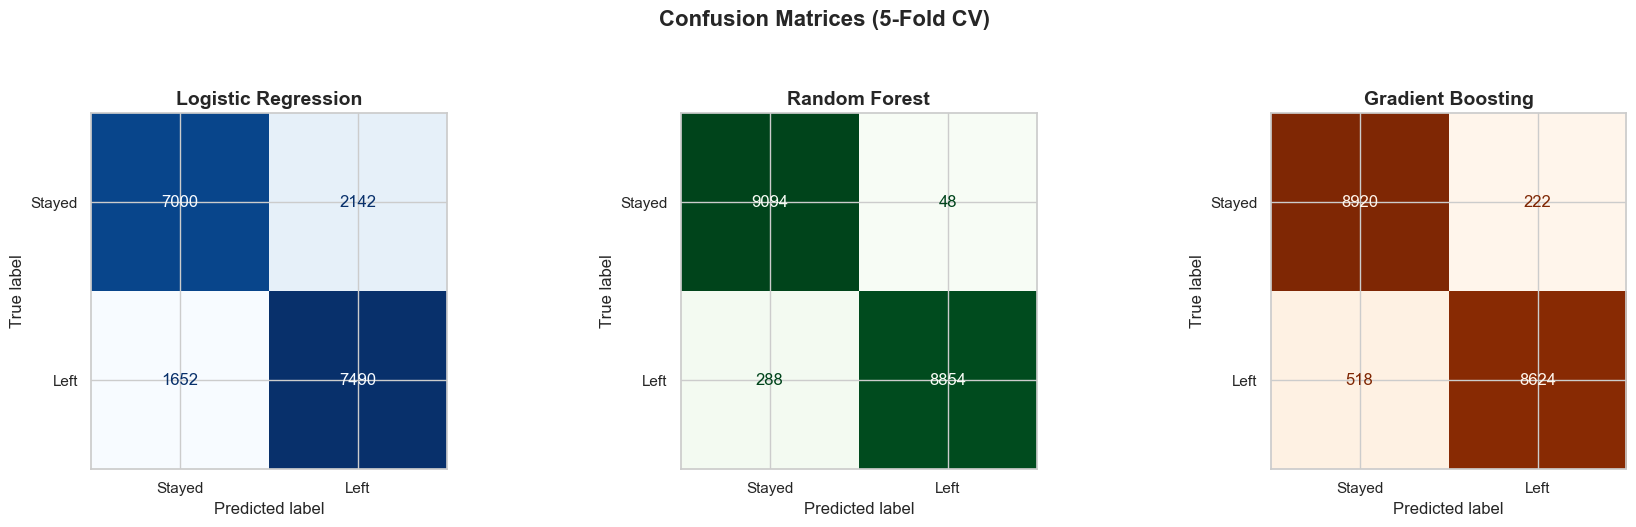

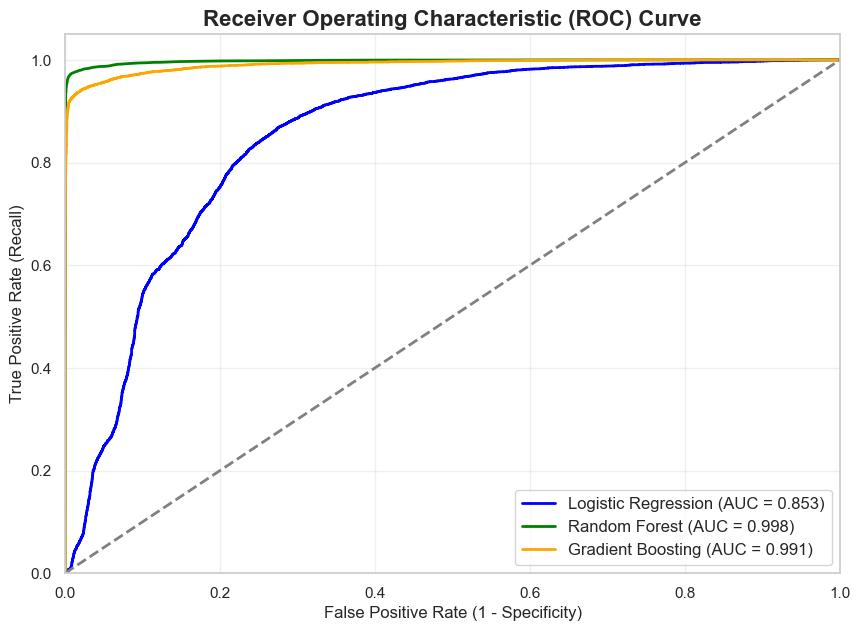

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# Step 1: In order to plot ROC/AUC, we need the "probability" scores 
# instead of just the strict 0 or 1 predictions.
# -----------------------------------------------------------------
from sklearn.model_selection import cross_val_predict

print("Generating probabilities for ROC/AUC curves...")
# Logistic Regression Probabilities
y_prob_lr = cross_val_predict(lr, X_train_smote, y_train_smote, cv=5, method='predict_proba')[:, 1]
# Random Forest Probabilities
y_prob_rf = cross_val_predict(rf, X_train_smote, y_train_smote, cv=5, method='predict_proba')[:, 1]
# Gradient Boosting Probabilities
y_prob_gbc = cross_val_predict(gbc, X_train_smote, y_train_smote, cv=5, method='predict_proba')[:, 1]

# -----------------------------------------------------------------
# Step 2: Plot Confusion Matrices
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot for Logistic Regression
cm_lr = confusion_matrix(y_train_smote, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Stayed', 'Left'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression', fontsize=14, weight='bold')

# Plot for Random Forest
cm_rf = confusion_matrix(y_train_smote, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stayed', 'Left'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest', fontsize=14, weight='bold')

# Plot for Gradient Boosting
cm_gbc = confusion_matrix(y_train_smote, y_pred_gbc)
disp_gbc = ConfusionMatrixDisplay(confusion_matrix=cm_gbc, display_labels=['Stayed', 'Left'])
disp_gbc.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Gradient Boosting', fontsize=14, weight='bold')

plt.suptitle('Confusion Matrices (5-Fold CV)', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------
# Step 3: Calculate AUC and Plot ROC Curves
# -----------------------------------------------------------------
# Get False Positive Rates and True Positive Rates
fpr_lr, tpr_lr, _ = roc_curve(y_train_smote, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_train_smote, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_gbc, tpr_gbc, _ = roc_curve(y_train_smote, y_prob_gbc)
roc_auc_gbc = auc(fpr_gbc, tpr_gbc)

plt.figure(figsize=(10, 7))

# Plot lines
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_gbc, tpr_gbc, color='orange', lw=2, label=f'Gradient Boosting (AUC = {roc_auc_gbc:.3f})')

# Plot diagnostic diagonal line representing a random guess
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, weight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


--- Current Employees at Risk of Leaving ---
Risk_Zone
Safe Zone (Green)            2141
Low-Risk Zone (Yellow)        136
Medium-Risk Zone (Orange)       5
High-Risk Zone (Red)            4
Name: count, dtype: int64


/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_5263/2232278414.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=current_employees, x='Risk_Zone', palette=colors,


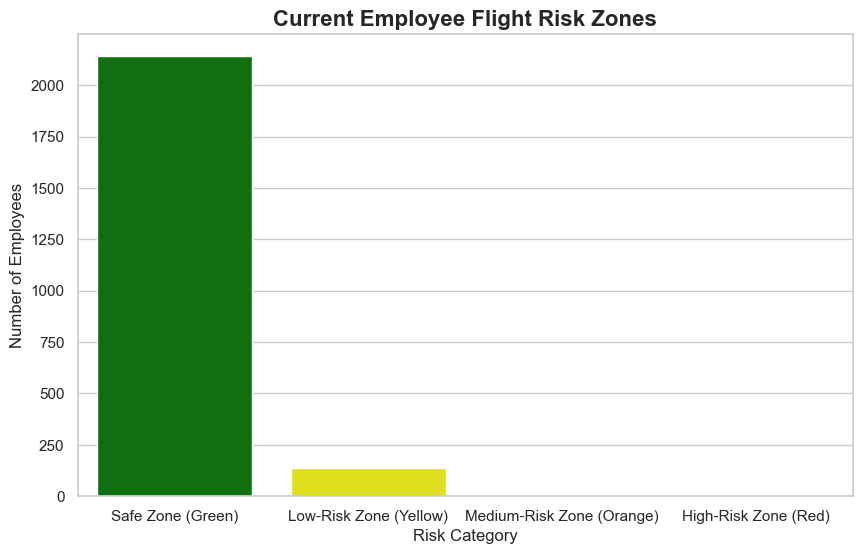

In [50]:

# 1. We identified Random Forest as the best model. 
# We need to re-fit it on the full SMOTE training data to ensure it's fully trained.
# (cross_val_predict only trained it internally for folds)
from sklearn.ensemble import RandomForestClassifier
rf_best = RandomForestClassifier(random_state=123)
rf_best.fit(X_train_smote, y_train_smote)

# 2. Predict the PROBABILITY of turnover for the X_test dataset
# Remember, X_test is data the model has never seen before!
test_probabilities = rf_best.predict_proba(X_test)[:, 1] # Get probabilities for Class 1 (Left)

# 3. Create a new DataFrame to hold the test results
results_df = pd.DataFrame({
    'Actual_Status': y_test,
    'Turnover_Probability': test_probabilities
})

# 4. Filter the dataframe to only look at CURRENT employees (Actual_Status == 0)
# We can't retain people who already left!
current_employees = results_df[results_df['Actual_Status'] == 0].copy()

# 5. Define a function to categorize the risk zones
def categorize_risk(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif prob < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

# Apply the function to create a new column
current_employees['Risk_Zone'] = current_employees['Turnover_Probability'].apply(categorize_risk)

# 6. Print the distribution of employees in each zone
print("--- Current Employees at Risk of Leaving ---")
zone_counts = current_employees['Risk_Zone'].value_counts()
print(zone_counts)


plt.figure(figsize=(10, 6))
# Define exact colors for the zones
colors = {'Safe Zone (Green)': 'green', 
          'Low-Risk Zone (Yellow)': 'yellow', 
          'Medium-Risk Zone (Orange)': 'orange', 
          'High-Risk Zone (Red)': 'red'}

sns.countplot(data=current_employees, x='Risk_Zone', palette=colors, 
              order=['Safe Zone (Green)', 'Low-Risk Zone (Yellow)', 'Medium-Risk Zone (Orange)', 'High-Risk Zone (Red)'])
plt.title('Current Employee Flight Risk Zones', fontsize=16, weight='bold')
plt.ylabel('Number of Employees')
plt.xlabel('Risk Category')
plt.show()


=== RANDOM FOREST TEST SET PERFORMANCE ===
Accuracy:  0.9897
Recall:    0.9818  <-- (Crucial: % of leavers we actually caught)
Precision: 0.9750
F1-Score:  0.9784

Most Influential Features (Raw Scores):
                 Feature  Importance
0     satisfaction_level    0.254439
4     time_spend_company    0.229539
2         number_project    0.167594
3   average_montly_hours    0.154006
1        last_evaluation    0.128387
5          Work_accident    0.023250
7                 salary    0.018028
14      Department_sales    0.004594
16  Department_technical    0.003834
15    Department_support    0.002889


/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_5263/2799065438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


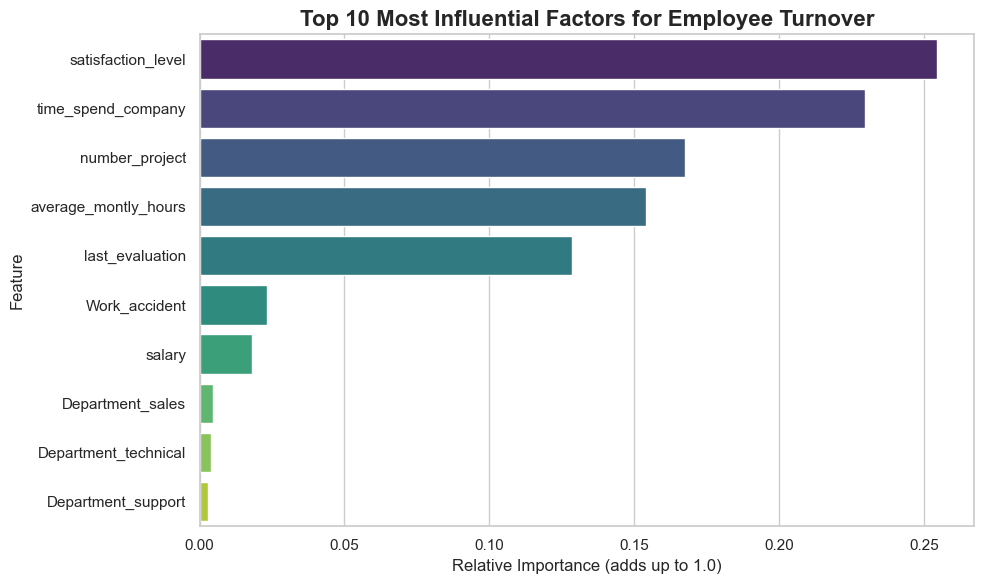

In [51]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

y_pred_test_rf = rf_best.predict(X_test)

# 2. Calculate and Print the exact metrics for the Test Set
print("=== RANDOM FOREST TEST SET PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_rf):.4f}  <-- (Crucial: % of leavers we actually caught)")
print(f"Precision: {precision_score(y_test, y_pred_test_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_rf):.4f}")
print("==========================================\n")

# 3. Extract Feature Importances
# Random Forest mathematically ranks how much each column influenced the splits in its trees
importances = rf_best.feature_importances_
feature_names = X_train_smote.columns

# 4. Create a DataFrame to sort and view the importances cleanly
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Most Influential Features (Raw Scores):")
print(feature_importance_df.head(10)) # Print top 10

# 5. Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10), # Plotting Top 10 to keep it clean
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title('Top 10 Most Influential Factors for Employee Turnover', fontsize=16, weight='bold')
plt.xlabel('Relative Importance (adds up to 1.0)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()
